In [1]:
from google.colab import files
uploaded = files.upload()

Saving monthly_milk_production (3).csv to monthly_milk_production (3).csv


In [5]:
import pandas as pd

df = pd.read_csv('monthly_milk_production (3).csv')

df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [6]:
import os

print(os.listdir())

['.config', 'monthly_milk_production (3).csv', 'sample_data']


In [7]:
print(df.columns)

df.head()

Index(['Date', 'Production'], dtype='object')


,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv('monthly_milk_production (3).csv')

df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [10]:
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [11]:
print(df.shape)

print("\nMissing Values")
print(df.isnull().sum())

df.describe()

(168, 1)

Missing Values
Production    0
dtype: int64


,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


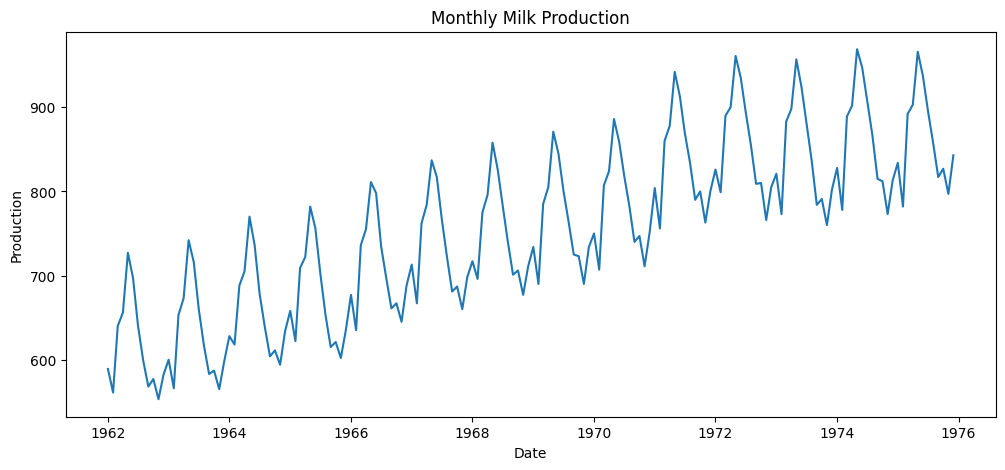

In [12]:
plt.figure(figsize=(12,5))
plt.plot(df['Production'])
plt.title('Monthly Milk Production')
plt.xlabel('Date')
plt.ylabel('Production')
plt.show()

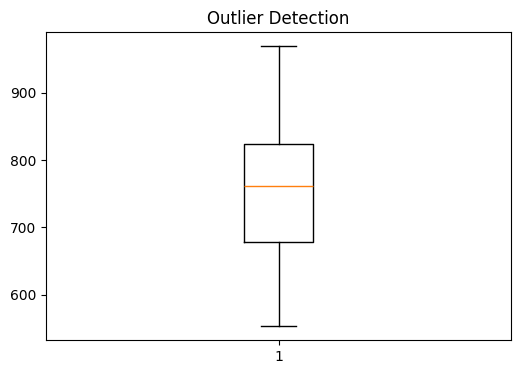

In [13]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Production'])
plt.title('Outlier Detection')
plt.show()

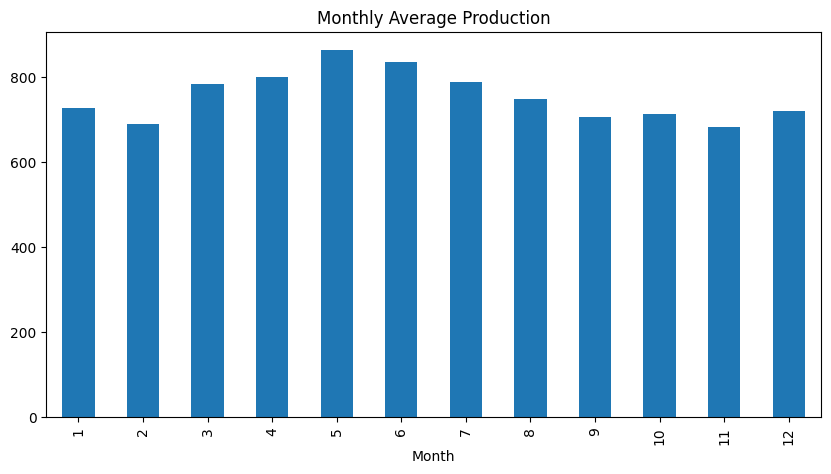

In [14]:
df['Month'] = df.index.month

monthly_avg = df.groupby('Month')['Production'].mean()

plt.figure(figsize=(10,5))
monthly_avg.plot(kind='bar')
plt.title('Monthly Average Production')
plt.show()

In [15]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[['Production']])

scaled_data[:5]

array([[0.08653846],
       [0.01923077],
       [0.20913462],
       [0.24759615],
       [0.41826923]])

In [16]:
window_size = 12

X = []
y = []

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i,0])
    y.append(scaled_data[i,0])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(156, 12)
(156,)


In [17]:
X = X.reshape(X.shape[0], X.shape[1], 1)

print(X.shape)

(156, 12, 1)


In [18]:
train_size = int(len(X)*0.70)
val_size = int(len(X)*0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(109, 12, 1)
(23, 12, 1)
(24, 12, 1)


In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [20]:
rnn_model = Sequential()

rnn_model.add(SimpleRNN(50, input_shape=(window_size,1)))
rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0556 - val_loss: 0.0479
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0200 - val_loss: 0.0086
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0105 - val_loss: 0.0259
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0063 - val_loss: 0.0051
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0051 - val_loss: 0.0116
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0043 - val_loss: 0.0050
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0030 - val_loss: 0.0056
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0026 - val_loss: 0.0042
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0023 - val_loss: 0.0037
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0021 - val_loss: 0.0044
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0020 - val_loss: 0.0036
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0024 - val_loss: 0.0033
E

In [21]:
lstm_model = Sequential()

lstm_model.add(LSTM(50, input_shape=(window_size,1)))
lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.1365 - val_loss: 0.1713
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0420 - val_loss: 0.0288
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0312 - val_loss: 0.0373
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0294 - val_loss: 0.0276
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0249 - val_loss: 0.0376
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0256 - val_loss: 0.0346
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0238 - val_loss: 0.0265
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0245 - val_loss: 0.0249
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0236 - val_loss: 0.0273
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0232 - val_loss: 0.0288


In [22]:
gru_model = Sequential()

gru_model.add(GRU(50, input_shape=(window_size,1)))
gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.1534 - val_loss: 0.2079
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0480 - val_loss: 0.0480
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0299 - val_loss: 0.0257
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0330 - val_loss: 0.0259
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0251 - val_loss: 0.0406
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0242 - val_loss: 0.0461
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0238 - val_loss: 0.0379
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0225 - val_loss: 0.0305
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0218 - val_loss: 0.0281
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0211 - val_loss: 0.0305


In [23]:
def evaluate_model(model):

    pred = model.predict(X_test)

    pred_inv = scaler.inverse_transform(pred)

    actual_inv = scaler.inverse_transform(
        y_test.reshape(-1,1)
    )

    rmse = np.sqrt(
        mean_squared_error(actual_inv,pred_inv)
    )

    mae = mean_absolute_error(
        actual_inv,pred_inv
    )

    mape = np.mean(
        np.abs(
            (actual_inv-pred_inv)/actual_inv
        )
    )*100

    return pred_inv, actual_inv, rmse, mae, mape

In [24]:
rnn_pred, actual, rnn_rmse, rnn_mae, rnn_mape = evaluate_model(rnn_model)

lstm_pred, _, lstm_rmse, lstm_mae, lstm_mape = evaluate_model(lstm_model)

gru_pred, _, gru_rmse, gru_mae, gru_mape = evaluate_model(gru_model)

results = pd.DataFrame({
    'Model':['RNN','LSTM','GRU'],
    'RMSE':[rnn_rmse,lstm_rmse,gru_rmse],
    'MAE':[rnn_mae,lstm_mae,gru_mae],
    'MAPE':[rnn_mape,lstm_mape,gru_mape]
})

results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step


,Model,RMSE,MAE,MAPE
0,RNN,15.042330,12.482381,1.442346
1,LSTM,179.659813,168.863813,19.236103
2,GRU,197.987535,188.707316,21.568843


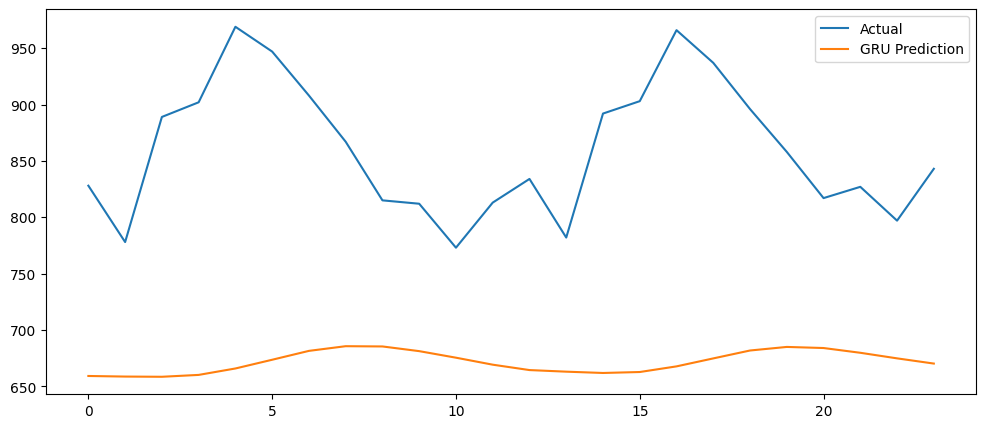

In [25]:
plt.figure(figsize=(12,5))

plt.plot(actual,label='Actual')
plt.plot(gru_pred,label='GRU Prediction')

plt.legend()
plt.show()

In [26]:
best_model = gru_model

last_sequence = scaled_data[-window_size:]

future_predictions = []

current_seq = last_sequence.copy()

for i in range(12):

    pred = best_model.predict(
        current_seq.reshape(1,window_size,1),
        verbose=0
    )

    future_predictions.append(pred[0,0])

    current_seq = np.vstack(
        (current_seq[1:], pred)
    )

future_predictions = np.array(
    future_predictions
).reshape(-1,1)

future_predictions = scaler.inverse_transform(
    future_predictions
)

future_predictions

array([[667.2443 ],
       [661.112  ],
       [650.32214],
       [640.2402 ],
       [632.0959 ],
       [625.79626],
       [621.0458 ],
       [617.493  ],
       [614.84436],
       [612.8761 ],
       [611.3965 ],
       [610.3014 ]], dtype=float32)

In [27]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

forecast_df = pd.DataFrame({
    'Date':future_dates,
    'Forecast':future_predictions.flatten()
})

forecast_df

,Date,Forecast
0,1976-01-01,667.244324
1,1976-02-01,661.112000
2,1976-03-01,650.322144
3,1976-04-01,640.240173
4,1976-05-01,632.095886
5,1976-06-01,625.796265
6,1976-07-01,621.045776
7,1976-08-01,617.492981
8,1976-09-01,614.844360
9,1976-10-01,612.876099


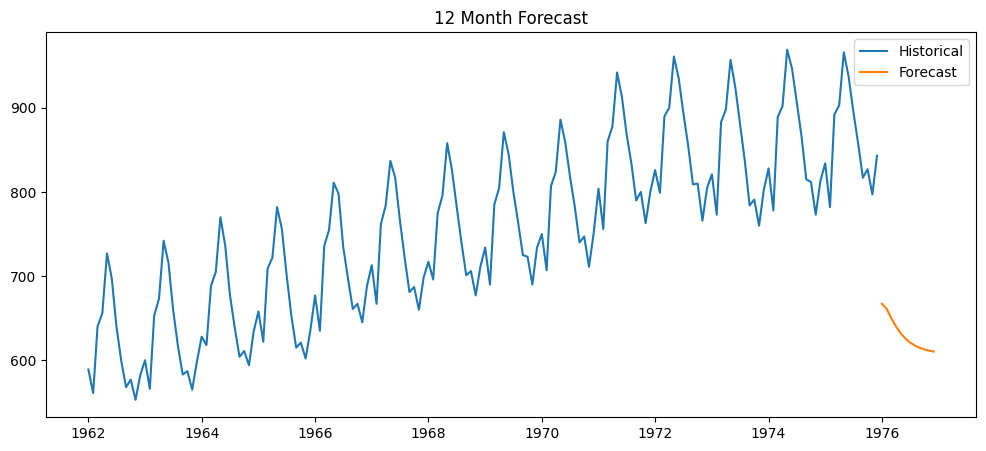

In [28]:
plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    df['Production'],
    label='Historical'
)

plt.plot(
    forecast_df['Date'],
    forecast_df['Forecast'],
    label='Forecast'
)

plt.legend()
plt.title('12 Month Forecast')

plt.show()

In [29]:
print("1. Forecasts help predict future milk production.")
print("2. Inventory planning can be improved.")
print("3. Seasonal production changes can be anticipated.")
print("4. Workforce allocation becomes easier.")
print("5. Dairy businesses can optimize supply chain decisions.")

1. Forecasts help predict future milk production.
2. Inventory planning can be improved.
3. Seasonal production changes can be anticipated.
4. Workforce allocation becomes easier.
5. Dairy businesses can optimize supply chain decisions.


In [30]:
forecast_df['Lower'] = forecast_df['Forecast'] * 0.95
forecast_df['Upper'] = forecast_df['Forecast'] * 1.05

forecast_df.head()


,Date,Forecast,Lower,Upper
0,1976-01-01,667.244324,633.882080,700.606506
1,1976-02-01,661.112000,628.056396,694.167542
2,1976-03-01,650.322144,617.806030,682.838196
3,1976-04-01,640.240173,608.228149,672.252136
4,1976-05-01,632.095886,600.491089,663.700623


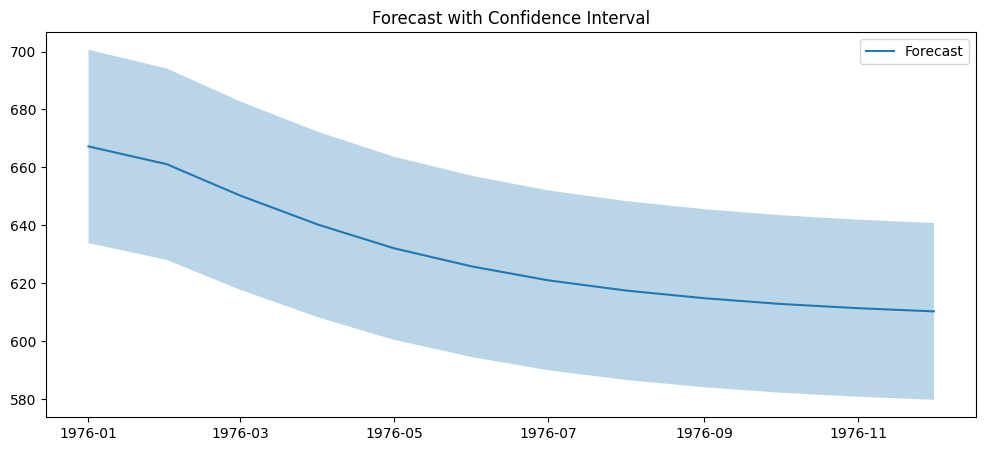

In [31]:
plt.figure(figsize=(12,5))

plt.plot(
    forecast_df['Date'],
    forecast_df['Forecast'],
    label='Forecast'
)

plt.fill_between(
    forecast_df['Date'],
    forecast_df['Lower'],
    forecast_df['Upper'],
    alpha=0.3
)

plt.title('Forecast with Confidence Interval')
plt.legend()
plt.show()

In [32]:
print("""
Hyperparameters Used:
Window Size = 12
Units = 50
Batch Size = 16
Epochs = 50
Optimizer = Adam
Loss Function = MSE
""")


Hyperparameters Used:
Window Size = 12
Units = 50
Batch Size = 16
Epochs = 50
Optimizer = Adam
Loss Function = MSE

